# Двухэтапная рекомендательная система: retrieval + ranking

Промышленные рекомендательные системы почти всегда двухуровневые: быстрая модель отбирает из всего каталога несколько сотен кандидатов, а тяжёлая ранжирует уже только их. Здесь я собираю такую схему целиком на задаче рекомендации музыки и проверяю, сколько именно качества даёт второй уровень.

Первый уровень — два независимых кандидатогенератора. Memory-based User2User на мере Жаккара и модель со скрытыми переменными, для которой выведены и реализованы три способа оптимизации: SGD, Alternating Least Squares и iALS для неявной обратной связи. Оба возвращают по 100 кандидатов на пользователя.

Второй уровень — CatBoost поверх объединённого пула кандидатов. Для каждой пары (пользователь, трек) собираются признаки: косинусное сходство эмбеддингов, средняя мера Жаккара, популярность трека и активность пользователя. Дальше сравниваются две постановки — CatBoostClassifier, обучаемый на парах независимо, и CatBoostRanker с YetiRank, который оптимизирует порядок внутри группы одного пользователя.

Качество меряется через MAP@k, метрика реализована вручную.

Стек: CatBoost (Classifier + Ranker), NumPy/SciPy (разреженные матрицы), pandas.

---


## Постановка задачи

В этом проекте решается задача рекомендации музыки: для каждого пользователя нужно вернуть набор треков, наиболее похожих на те, что он уже слушал. В первой части рассматривается memory-based подход и модель со скрытыми переменными — не самые мощные методы, но зато почти мгновенные в применении. Во второй части используется то, что датасет содержит огромное число треков: результаты уже построенных быстрых моделей сокращают список кандидатов до разумного количества, после чего кандидаты ранжируются более сильной, но чуть более медленной моделью, и отбираются лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображён на картинке.

![](https://i.ibb.co/4RptSVjp/Screenshot-2026-03-23-at-00-29-18.png)

Приступим.

In [263]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [265]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [267]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

Реализуем метрику $MAP@k$.

In [271]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    def apk(rel_set, pred, k):
        pred = pred[:k]
        hits, score = 0, 0.0
        for i, item in enumerate(pred):
            if item in rel_set:
                hits += 1
                score += hits / (i + 1)
        return score / min(k, len(rel_set)) if rel_set else 0.0

    return np.mean([
        apk(set(rel), pred, k)
        for rel, pred in zip(relevant, predicted)
    ])

In [273]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [405]:
def train_test_split(ratings):
    train_list, test_list = [], []
    num_test_samples = 50

    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_list.append(user_data[:-num_test_samples])
        test_list.append(user_data[-num_test_samples:])

    train_ratings = pd.concat(train_list).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    filtered_test = []
    for test_chunk in test_list:
        filtered_test.append(
            test_chunk[np.isin(test_chunk['trackId'], all_train_items)]
        )

    test_ratings = pd.concat(filtered_test).reset_index(drop=True)
    return train_ratings, test_ratings

In [278]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [281]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [283]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())
    
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [285]:
uencoder, iencoder = ids_encoder(train_ratings)

train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

train_ratings['userId'] = uencoder.transform(train_ratings['userId'].tolist())
test_ratings['userId'] = uencoder.transform(test_ratings['userId'].tolist())

In [287]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [289]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [292]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

Реализуем метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Важно удалять уже прослушанные треки из рекомендуемых.

In [295]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.
        
    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []
        for user_id in tqdm(range(self.n_users)):
            user_recs = self.recommend(user_id)
            test_preds.append(user_recs)
    
        test_preds = np.array(test_preds)              
        test_preds = self.remove_train_items(test_preds, k)
        return test_preds[test_users]

### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах 
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

Реализуем функцию подсчёта меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$, а возвращает вектор со значениями похожести пользователя $u$ на всех остальных. Реализация векторизованная — на полной матрице оценок наивный цикл работает неприемлемо долго.

In [300]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    intersection = ratings @ user_vector  
    
    user_counts = ratings.sum(axis=1)          
    target_count = user_vector.sum()           
    union = user_counts + target_count - intersection  
    
    return np.where(union > 0, intersection / union, 0.0)

Реализуем методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные по убыванию предсказанных оценок. Параметр `alpha` подбираю так, чтобы множество соседей получалось разумного размера.

In [376]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.similarity_func = jaccard
        self.alpha = 0.01

    def similarity(self, user_vector: np.array):
        sim = self.similarity_func(self.R, user_vector)
        sim[sim <= self.alpha] = 0.0
        return sim

    def recommend(self, uid: int):
        user_vector = self.R[uid]
        sim = self.similarity(user_vector)
        sim[uid] = 0.0

        scores_num = sim @ self.R  

        denom = np.abs(sim).sum() + 1e-9
        scores = scores_num / denom

        return np.argsort(scores)[::-1]    

Построим график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендациями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

In [379]:
class RandomModel(BaseModel):
    def recommend(self, uid: int):
        scores = np.random.rand(self.n_items)
        return np.argsort(scores)[::-1]

class PopularModel(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.popularity = self.R.sum(axis=0)  

    def recommend(self, uid: int):
        return np.argsort(self.popularity)[::-1]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

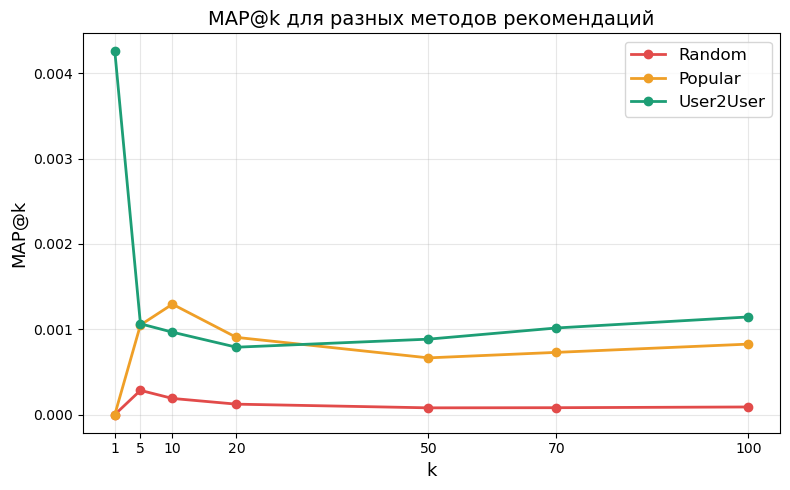

Random      : MAP@1=0.0000  MAP@5=0.0003  MAP@10=0.0002  MAP@20=0.0001  MAP@50=0.0001  MAP@70=0.0001  MAP@100=0.0001
Popular     : MAP@1=0.0000  MAP@5=0.0010  MAP@10=0.0013  MAP@20=0.0009  MAP@50=0.0007  MAP@70=0.0007  MAP@100=0.0008
User2User   : MAP@1=0.0043  MAP@5=0.0011  MAP@10=0.0010  MAP@20=0.0008  MAP@50=0.0009  MAP@70=0.0010  MAP@100=0.0011


In [381]:
k_values = [1, 5, 10, 20, 50, 70, 100]

random_model = RandomModel(train_ratings)
popular_model = PopularModel(train_ratings)
u2u_model = User2User(train_ratings)

random_preds = random_model.get_test_recommendations(k=max(k_values))
popular_preds = popular_model.get_test_recommendations(k=max(k_values))
u2u_preds = u2u_model.get_test_recommendations(k=max(k_values))

results = {'k': k_values, 'Random': [], 'Popular': [], 'User2User': []}

for k in k_values:
    results['Random'].append(mapk(test_relevant, random_preds[:, :k].tolist(), k))
    results['Popular'].append(mapk(test_relevant, popular_preds[:, :k].tolist(), k))
    results['User2User'].append(mapk(test_relevant, u2u_preds[:, :k].tolist(), k))

plt.figure(figsize=(8, 5))
for model_name, color in [('Random', '#E24B4A'), ('Popular', '#EF9F27'), ('User2User', '#1D9E75')]:
    plt.plot(k_values, results[model_name], marker='o', label=model_name, color=color, linewidth=2)

plt.xlabel('k', fontsize=13)
plt.ylabel('MAP@k', fontsize=13)
plt.title('MAP@k для разных методов рекомендаций', fontsize=14)
plt.xticks(k_values)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for model_name in ['Random', 'Popular', 'User2User']:
    print(f"{model_name:12s}: " + "  ".join(f"MAP@{k}={v:.4f}" for k, v in zip(k_values, results[model_name])))

>  Лучшим методом оказался User2User.

> С ростом количества наиболее подходящих треков до 20~ Popular догоняет User2User по качеству.
>  При большом количестве рекомендаций персонализация User2User чуть лучше.

>  Для User2User топ рекомендаций формируется треками с высоким взвешенным score (их слушало много похожих пользователей). При росте k в список попадают треки с низким score, которые подходят малому количеству соседей - это такие рекомендации менее надежны. В то время как Popular просто перебирает треки от самых популярных к менее популярным. При большом k в список попадают треки, которые мало кто слушал, и вероятность угадать интересы конкретного пользователя падает.

>  Random стабильно показывает наихудшие результаты.

Матрица оценок получается очень разреженной, но пока работаем с ней как с плотной. Перепишу код так, чтобы все методы поддерживали разреженные матрицы, и сравню скорость с исходным вариантом.

In [387]:
import scipy.sparse as scs
import time

def jaccard_sparse(ratings: scs.csr_matrix, user_vector: scs.csr_matrix) -> np.array:
    intersection = ratings.dot(user_vector.T).toarray().ravel()
    items_per_user = np.array(ratings.sum(axis=1)).ravel()
    user_size = user_vector.nnz
    union = items_per_user + user_size - intersection
    return np.where(union > 0, intersection / union, 0.0)


class BaseModelSparse(BaseModel):
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))
        self.R = scs.csr_matrix(
            (np.ones(len(self.ratings)),
             (self.ratings['userId'], self.ratings['trackId'])),
            shape=(self.n_users, self.n_items)
        )

    def remove_train_items(self, preds: List[List[int]], k: int):
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]
        return new_preds


class User2UserSparse(BaseModelSparse):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.similarity_func = jaccard_sparse
        self.alpha = 0.01
        

    def similarity(self, user_vector: scs.csr_matrix):
        sim = self.similarity_func(self.R, user_vector)
        sim[sim <= self.alpha] = 0.0
        return sim

    def recommend(self, uid: int):
        user_vector = self.R[uid]
        sim = self.similarity(user_vector)
        sim[uid] = 0.0

        scores_num = sim @ self.R
        if scs.issparse(scores_num):
            scores_num = scores_num.toarray().ravel()

        denom = np.abs(sim).sum() + 1e-9
        scores = scores_num / denom

        return np.argsort(scores)[::-1]


class RandomModelSparse(BaseModelSparse):
    def recommend(self, uid: int):
        return np.argsort(np.random.rand(self.n_items))[::-1]


class PopularModelSparse(BaseModelSparse):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.popularity = np.array(self.R.sum(axis=0)).ravel()

    def recommend(self, uid: int):
        return np.argsort(self.popularity)[::-1]


N_BENCH_USERS = 20

dense_model = User2User(train_ratings)
sparse_model = User2UserSparse(train_ratings)

t0 = time.time()
for uid in range(N_BENCH_USERS):
    dense_model.recommend(uid)
t_dense = time.time() - t0

t0 = time.time()
for uid in range(N_BENCH_USERS):
    sparse_model.recommend(uid)
t_sparse = time.time() - t0

print(f"Плотная матрица ({N_BENCH_USERS} пользователей): {t_dense:.3f} сек")
print(f"Разреженная CSR ({N_BENCH_USERS} пользователей): {t_sparse:.3f} сек")
print(f"Ускорение: {t_dense / t_sparse:.2f}x")

Плотная матрица (20 пользователей): 0.490 сек
Разреженная CSR (20 пользователей): 0.045 сек
Ускорение: 10.86x


Посмотрим глазами, насколько разумно модель рекомендует треки: сравним уже прослушанное с рекомендованным и релевантным для случайного пользователя.

In [390]:
u2u_sparse = User2UserSparse(train_ratings)

model = u2u_sparse

In [392]:
user_id = np.random.randint(0, model.n_users)

In [394]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info[tracks_info['id'].isin(listened_tracks)][['name', 'artists']]

Already listened tracks:


,name,artists
805,Zombie,['The Cranberries']
1033,Somebody's Watching Me,['Rockwell']
1073,Smells Like Teen Spirit,['Nirvana']
1195,Umbrella,"['Rihanna', 'Jay-Z']"
2415,Hung Up,['Madonna']
4358,I Kissed A Girl,['Katy Perry']
6119,Smooth Criminal,['Michael Jackson']
6136,Billie Jean,['Michael Jackson']
6571,Love The Way You Lie,"['Eminem', 'Rihanna']"
6925,Toxic,['Britney Spears']


In [396]:
preds = model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

  0%|          | 0/241 [00:00<?, ?it/s]

Predicted tracks:


,name,artists
1019,It's My Life,['Bon Jovi']
2767,What I've Done,['Linkin Park']
7533,Highway to Hell,['AC/DC']
2555,Californication,['Red Hot Chili Peppers']
11493,The Show Must Go On,['Queen']
5872,Я свободен,['Кипелов']
1137,Nothing Else Matters,['Metallica']
5521,Полковнику никто не пишет,['Би-2']
49577,Кукла колдуна,['Король и Шут']
8263,Shape Of My Heart,['Sting']


In [398]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15].values

print('Test-time tracks:')

tracks_info.iloc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
67014,No Love,['АДЛИН']
67021,Дом Периньон,"['Пошлая Молли', 'Элджей']"
67027,From Tha Back Miss The Rage,['Framed']
67144,TRAXXXMANIA,['GONE.Fludd']
67156,Ghoul,['Twinky']
67178,МАЛИНОВАЯ ЛАДА,['GAYAZOV$ BROTHER$']
67181,БИЗНЕС ВУМЕН,"['SLAVA MARLOW', 'Aarne']"
67216,all I want is you,"['Rebzyyx', 'hoshie star']"
67219,Dead Inside,['АДЛИН']
67259,masquerade,['siouxxie sixxsta']


> В целом User2User улавливает жанровую близость, хотя точные попадания редки.

### Часть 2. Модель со скрытыми переменными: ALS

В этой части рассматривается метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно. 

Оптимизировать будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметим, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS. Ниже реализован и он.

Есть два подхода к оптимизации параметров этой модели: обычный стохастический градиентный спуск, либо поочерёдное обновление матриц $P, Q$ — метод Alternating Least Squares (ALS). Ниже выведены формулы обновления параметров для обоих методов.

**SGD:**

Градиент потерь по $p_u$ и $q_i$ для одной пары $(u, i)$:

$$\frac{\partial L}{\partial p_u} = -2(r_{ui} - \hat{r}_{ui})\,q_i + 2\lambda p_u$$

$$\frac{\partial L}{\partial q_i} = -2(r_{ui} - \hat{r}_{ui})\,p_u + 2\lambda q_i$$

Правило обновления:

$$p_u \leftarrow p_u + \eta\,(r_{ui} - \hat{r}_{ui})\,q_i - \eta\lambda\, p_u$$

$$q_i \leftarrow q_i + \eta\,(r_{ui} - \hat{r}_{ui})\,p_u - \eta\lambda\, q_i$$


**ALS:**

Фиксируем $Q$, обновляем строки $P$:

$$p_u \leftarrow \left(Q_u^\top Q_u + \lambda I\right)^{-1} Q_u^\top r_u$$

Фиксируем $P$, обновляем строки $Q$:

$$q_i \leftarrow \left(P_i^\top P_i + \lambda I\right)^{-1} P_i^\top r_i$$

где $Q_u$ - подматрица строк $Q$ для треков, прослушанных пользователем $u$,
$P_i$ - подматрица строк $P$ для пользователей, слушавших трек $i$,
$r_u$, $r_i$ - соответствующие векторы оценок.

Реализуем методы оптимизации параметров для обоих алгоритмов.

In [336]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(scale=0.01, size=(self.n_users, dim))
        self.Q = np.random.normal(scale=0.01, size=(self.n_items, dim))

        self.lr = 0.01
        self.lamb = 0.01

        self._user_items = {
            u: grp['trackId'].values
            for u, grp in ratings.groupby('userId')
        }
        self._item_users = {
            i: grp['userId'].values
            for i, grp in ratings.groupby('trackId')
        }

    def fit(self, num_iters=5):
        users = self.ratings['userId'].values
        items = self.ratings['trackId'].values

        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                idx = np.random.permutation(len(users))
                for k in idx:
                    u, i = users[k], items[k]
                    err = 1.0 - self.P[u] @ self.Q[i]
                    p_old = self.P[u].copy()
                    self.P[u] += self.lr * (err * self.Q[i] - self.lamb * self.P[u])
                    self.Q[i] += self.lr * (err * p_old   - self.lamb * self.Q[i])

            elif self.mode == 'als':
                for u, item_ids in self._user_items.items():
                    Q_u = self.Q[item_ids]
                    r_u = np.ones(len(item_ids)) # r_ui = 1 для всех наблюдаемых пар
                    A = Q_u.T @ Q_u + self.lamb * np.eye(self.dim)
                    b = Q_u.T @ r_u
                    self.P[u] = np.linalg.solve(A, b)

                for i, user_ids in self._item_users.items():
                    P_i = self.P[user_ids]
                    r_i = np.ones(len(user_ids))   
                    A = P_i.T @ P_i + self.lamb * np.eye(self.dim)
                    b = P_i.T @ r_i
                    self.Q[i] = np.linalg.solve(A, b)

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T
        return np.argsort(pred_rating)[::-1]

Для обоих алгоритмов подберём оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$, посмотрим, как меняется качество с числом итераций обучения, и сравним со случайными рекомендациями и User2User.

Замечание про SGD: он склонен переобучаться, поэтому при подборе параметров полезно смотреть на ошибку и оптимизируемую метрику ещё и на обучающей выборке. Начальную инициализацию и прочие параметры, кроме архитектуры, тоже имеет смысл варьировать.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

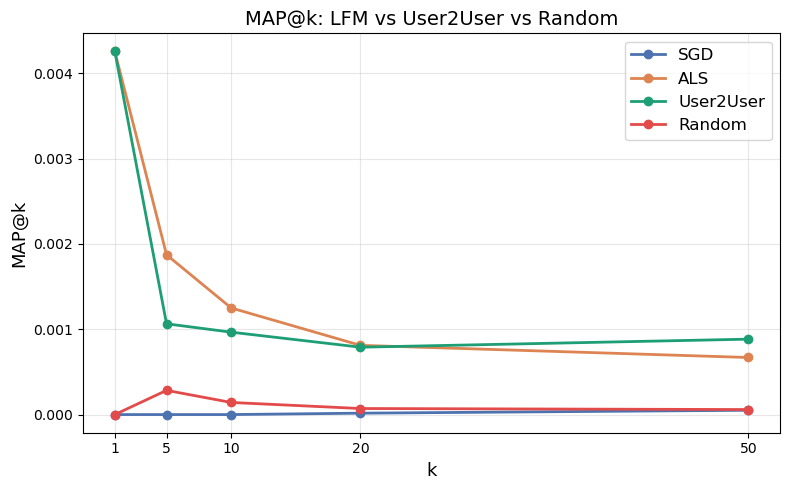

SGD         : MAP@1=0.0000  MAP@5=0.0000  MAP@10=0.0000  MAP@20=0.0000  MAP@50=0.0001
ALS         : MAP@1=0.0043  MAP@5=0.0019  MAP@10=0.0012  MAP@20=0.0008  MAP@50=0.0007
User2User   : MAP@1=0.0043  MAP@5=0.0011  MAP@10=0.0010  MAP@20=0.0008  MAP@50=0.0009
Random      : MAP@1=0.0000  MAP@5=0.0003  MAP@10=0.0001  MAP@20=0.0001  MAP@50=0.0001


In [339]:
k_values = [1, 5, 10, 20, 50]

sgd_model = LatentFactorModel(train_ratings, dim=64, mode='sgd')
sgd_model.lr = 0.05      
sgd_model.lamb = 0.001   
sgd_model.fit(num_iters=5)
sgd_preds = sgd_model.get_test_recommendations(k=max(k_values))

als_model = LatentFactorModel(train_ratings, dim=64, mode='als')
als_model.fit(num_iters=5)
als_preds = als_model.get_test_recommendations(k=max(k_values))

results_lfm = {'k': k_values, 'SGD': [], 'ALS': [], 'User2User': [], 'Random': []}

for k in k_values:
    results_lfm['SGD'].append(mapk(test_relevant, sgd_preds[:, :k].tolist(), k))
    results_lfm['ALS'].append(mapk(test_relevant, als_preds[:, :k].tolist(), k))
    results_lfm['User2User'].append(mapk(test_relevant, u2u_preds[:, :k].tolist(), k))
    results_lfm['Random'].append(mapk(test_relevant, random_preds[:, :k].tolist(), k))

plt.figure(figsize=(8, 5))
colors = {'SGD': '#4C72B0', 'ALS': '#DD8452', 'User2User': '#1D9E75', 'Random': '#E24B4A'}
for name, color in colors.items():
    plt.plot(k_values, results_lfm[name], marker='o', label=name, color=color, linewidth=2)

plt.xlabel('k', fontsize=13)
plt.ylabel('MAP@k', fontsize=13)
plt.title('MAP@k: LFM vs User2User vs Random', fontsize=14)
plt.xticks(k_values)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name in ['SGD', 'ALS', 'User2User', 'Random']:
    print(f"{name:12s}: " + "  ".join(f"MAP@{k}={v:.4f}" for k, v in zip(k_values, results_lfm[name])))

> ALS лучше U2U, особенно при относительно небольших k

> С ростом размера предсказания размывается качество ранжирования, найти подходящие объекты становится труднее.

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

...

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

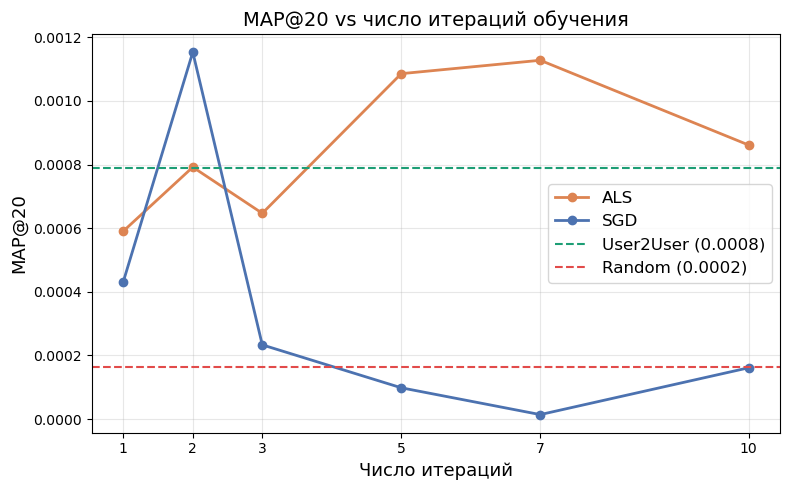

In [91]:
iter_values = [1, 2, 3, 5, 7, 10]
map_vs_iters = {'ALS': [], 'SGD': []}

for n_iter in tqdm(iter_values):
    m_als = LatentFactorModel(train_ratings, dim=64, mode='als')
    m_als.fit(num_iters=n_iter)
    p_als = m_als.get_test_recommendations(k=20)
    map_vs_iters['ALS'].append(mapk(test_relevant, p_als[:, :20].tolist(), k=20))
    
    m_sgd = LatentFactorModel(train_ratings, dim=64, mode='sgd')
    m_sgd.lr = 0.05
    m_sgd.lamb = 0.001
    m_sgd.fit(num_iters=n_iter)
    p_sgd = m_sgd.get_test_recommendations(k=20)
    map_vs_iters['SGD'].append(mapk(test_relevant, p_sgd[:, :20].tolist(), k=20))

map_u2u = mapk(test_relevant, u2u_preds[:, :20].tolist(), k=20)
map_rnd = mapk(test_relevant, random_preds[:, :20].tolist(), k=20)

plt.figure(figsize=(8, 5))
plt.plot(iter_values, map_vs_iters['ALS'], marker='o', label='ALS', color='#DD8452', linewidth=2)
plt.plot(iter_values, map_vs_iters['SGD'], marker='o', label='SGD', color='#4C72B0', linewidth=2)
plt.axhline(map_u2u, linestyle='--', color='#1D9E75', label=f'User2User ({map_u2u:.4f})')
plt.axhline(map_rnd, linestyle='--', color='#E24B4A', label=f'Random ({map_rnd:.4f})')

plt.xlabel('Число итераций', fontsize=13)
plt.ylabel('MAP@20', fontsize=13)
plt.title('MAP@20 vs число итераций обучения', fontsize=14)
plt.xticks(iter_values)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> ALS поочерёдно фиксирует P и оптимизирует Q, затем наоборот. Лучшее качество на 2-5 итерации.

> SGD обновляет P и Q на каждой паре (u, i) по градиенту. На разреженных данных модель быстро запоминает обучающую выборку, но не обобщает. Градиенты на редких треках шумят. Переобучается. 

Эти методы лучше всего работают при малом количестве итераций. ALS предпочтительнее для разреженных данных.

> ALS в общем превосходит User2User. 

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

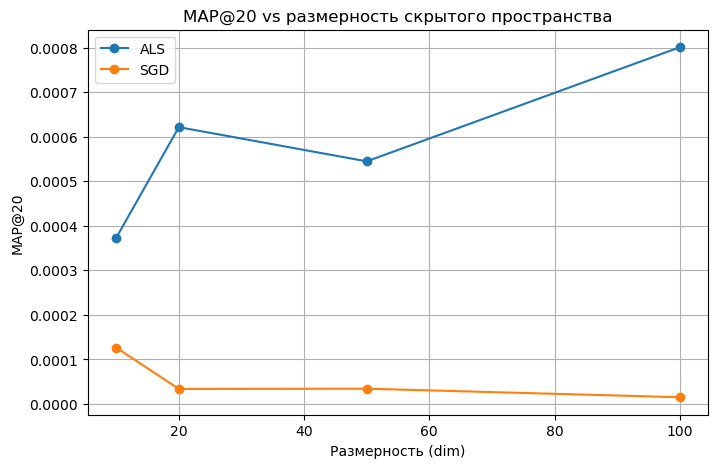

In [96]:
dims = [10, 20, 50, 100]

map_vs_dim = {'ALS': [], 'SGD': []}

for d in dims:
    m_als = LatentFactorModel(train_ratings, dim=d, mode='als')
    m_als.fit(num_iters=5)
    p_als = m_als.get_test_recommendations(k=20)
    map_vs_dim['ALS'].append(mapk(test_relevant, p_als[:, :20].tolist(), k=20))
    
    m_sgd = LatentFactorModel(train_ratings, dim=d, mode='sgd')
    m_sgd.lr = 0.05
    m_sgd.lamb = 0.001
    m_sgd.fit(num_iters=5)
    p_sgd = m_sgd.get_test_recommendations(k=20)
    map_vs_dim['SGD'].append(mapk(test_relevant, p_sgd[:, :20].tolist(), k=20))

plt.figure(figsize=(8, 5))
plt.plot(dims, map_vs_dim['ALS'], marker='o', label='ALS')
plt.plot(dims, map_vs_dim['SGD'], marker='o', label='SGD')

plt.xlabel('Размерность (dim)')
plt.ylabel('MAP@20')
plt.title('MAP@20 vs размерность скрытого пространства')
plt.legend()
plt.grid(True)
plt.show()

> По мере увеличения размерности скрытого пространства качество ALS монотонно растёт, тогда как SGD все равно.

In [125]:
als_model = LatentFactorModel(train_ratings, dim=100, mode='als')
als_model.fit(num_iters=2)
als_preds = als_model.get_test_recommendations(k=max(k_values))

sgd_model = LatentFactorModel(train_ratings, dim=10, mode='sgd')
sgd_model.lr = 0.05
sgd_model.lamb = 0.001
sgd_model.fit(num_iters=2)
sgd_preds = sgd_model.get_test_recommendations(k=max(k_values))

print("Лучшие параметры:")
print(f"ALS: dim=100, iters=2, k=5")
print(f"SGD: dim=10, iters=2, k=5")


for k in k_values:
    als_score = mapk(test_relevant, als_preds[:, :k].tolist(), k)
    sgd_score = mapk(test_relevant, sgd_preds[:, :k].tolist(), k)
    u2u_score = mapk(test_relevant, u2u_preds[:, :k].tolist(), k)
    print(f"k={k:2d} | ALS={als_score:.4f} | SGD={sgd_score:.4f} | U2U={u2u_score:.4f}")

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Лучшие параметры:
ALS: dim=100, iters=2, k=5
SGD: dim=10,  iters=2, k=5
k= 1 | ALS=0.0085 | SGD=0.0085 | U2U=0.0043
k= 5 | ALS=0.0021 | SGD=0.0021 | U2U=0.0011
k=10 | ALS=0.0018 | SGD=0.0011 | U2U=0.0010
k=20 | ALS=0.0012 | SGD=0.0008 | U2U=0.0008
k=50 | ALS=0.0009 | SGD=0.0006 | U2U=0.0009


При достаточно хорошем качестве обучения матрицы $Q$ похожим трекам соответствуют похожие векторы. Значит, для любого трека можно найти ближайшие к нему в латентном пространстве и проверить обученность модели вручную.

In [342]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

Q_norm = als_model.Q / (np.linalg.norm(als_model.Q, axis=1, keepdims=True) + 1e-8)
preds = Q_norm @ Q_norm[example_trackId]   

track_idxs = preds.argsort()[::-1][:20]

In [344]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']].copy()
similar_tracks['cosine_similarity'] = preds[track_idxs]
similar_tracks

,name,artists,cosine_similarity
5512,Выхода нет,['Сплин'],1.000000
5570,Моё сердце,['Сплин'],0.690880
2416,Numb / Encore,"['Linkin Park', 'Jay-Z']",0.689011
4551,A Little Less Conversation,"['Elvis Presley', 'JXL']",0.647895
954,The Next Episode,"['Dr. Dre', 'Snoop Dogg']",0.644350
1159,Can't Help Falling In Love,['Andrea Bocelli'],0.640423
878,Three Little Birds,"['Bob Marley', 'The Wailers']",0.636923
6711,September,"['Earth, Wind & Fire']",0.636273
2820,Somewhere I Belong,['Linkin Park'],0.636046
6773,Back in Black,['AC/DC'],0.634680


> ALS лучший из LFM подходов. SGD не подходит для данной задачи.


Построим модель iALS и сравните ее качество с обучением ALS и SGD.

In [132]:
class iALS(BaseModel):
    def __init__(self, ratings, dim=100, alpha=40, lamb=0.01):
        super().__init__(ratings)
        self.dim = dim
        self.alpha = alpha  
        self.lamb = lamb

        self.P = np.random.normal(scale=0.01, size=(self.n_users, dim))
        self.Q = np.random.normal(scale=0.01, size=(self.n_items, dim))


        self.user_items = {}
        self.item_users = {}
        for u, grp in ratings.groupby('userId'):
            self.user_items[u] = grp['trackId'].values
        for i, grp in ratings.groupby('trackId'):
            self.item_users[i] = grp['userId'].values

    def fit(self, num_iters=5):
        I = np.eye(self.dim)
        c = 1 + self.alpha 

        for epoch in tqdm(range(num_iters)):
            QTQ = self.Q.T @ self.Q
            for u in range(self.n_users):
                items = self.user_items.get(u, np.array([], dtype=int))
                if len(items) == 0:
                    continue
                Q_u = self.Q[items]
 
                A = QTQ + self.alpha * (Q_u.T @ Q_u) + self.lamb * I
                b = c * Q_u.sum(axis=0)  
                self.P[u] = np.linalg.solve(A, b)

            PTP = self.P.T @ self.P
            for i in range(self.n_items):
                users = self.item_users.get(i, np.array([], dtype=int))
                if len(users) == 0:
                    continue
                P_i = self.P[users]
                A = PTP + self.alpha * (P_i.T @ P_i) + self.lamb * I
                b = c * P_i.sum(axis=0)
                self.Q[i] = np.linalg.solve(A, b)

    def recommend(self, uid):
        scores = self.P[uid] @ self.Q.T
        return np.argsort(scores)[::-1]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

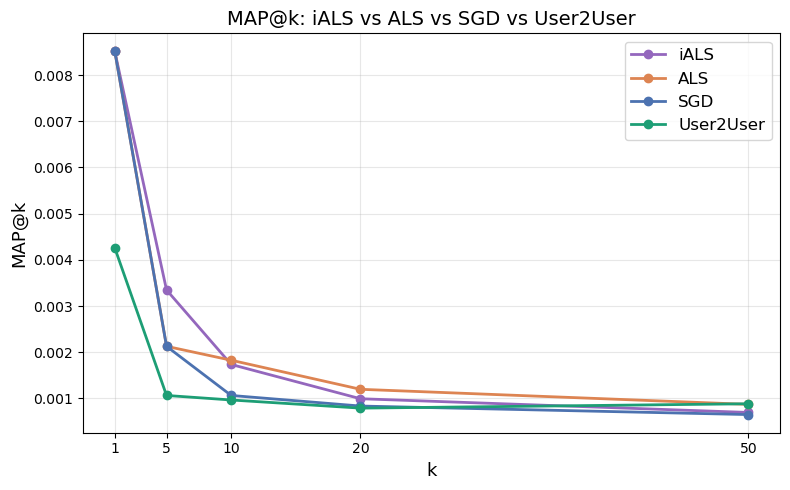

iALS        : MAP@1=0.0085  MAP@5=0.0033  MAP@10=0.0017  MAP@20=0.0010  MAP@50=0.0007
ALS         : MAP@1=0.0085  MAP@5=0.0021  MAP@10=0.0018  MAP@20=0.0012  MAP@50=0.0009
SGD         : MAP@1=0.0085  MAP@5=0.0021  MAP@10=0.0011  MAP@20=0.0008  MAP@50=0.0006
User2User   : MAP@1=0.0043  MAP@5=0.0011  MAP@10=0.0010  MAP@20=0.0008  MAP@50=0.0009


In [134]:
ials_model = iALS(train_ratings, dim=100, alpha=40, lamb=0.01)
ials_model.fit(num_iters=2)
ials_preds = ials_model.get_test_recommendations(k=max(k_values))

results_ials = {'k': k_values, 'iALS': [], 'ALS': [], 'SGD': [], 'User2User': []}
for k in k_values:
    results_ials['iALS'].append(mapk(test_relevant, ials_preds[:, :k].tolist(), k))
    results_ials['ALS'].append(mapk(test_relevant, als_preds[:, :k].tolist(), k))
    results_ials['SGD'].append(mapk(test_relevant, sgd_preds[:, :k].tolist(), k))
    results_ials['User2User'].append(mapk(test_relevant, u2u_preds[:, :k].tolist(), k))

plt.figure(figsize=(8, 5))
colors = {'iALS': '#9467BD', 'ALS': '#DD8452', 'SGD': '#4C72B0', 'User2User': '#1D9E75'}
for name, color in colors.items():
    plt.plot(k_values, results_ials[name], marker='o', label=name, color=color, linewidth=2)

plt.xlabel('k', fontsize=13)
plt.ylabel('MAP@k', fontsize=13)
plt.title('MAP@k: iALS vs ALS vs SGD vs User2User', fontsize=14)
plt.xticks(k_values)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name in ['iALS', 'ALS', 'SGD', 'User2User']:
    print(f"{name:12s}: " + "  ".join(f"MAP@{k}={v:.4f}" for k, v in zip(k_values, results_ials[name])))

> iALS чуть лучше классического ALS. Учёт неявной обратной связи помогает. 

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

Для каждого пользователя возьмём топ-100 рекомендованных треков от модели LFM и топ-100 от User2User. Это кандидаты, которые дальше будет ранжировать бустинг.

In [139]:
k_candidates = 100

als_candidates_full = als_model.get_test_recommendations(k=k_candidates)
u2u_candidates_full = u2u_model.get_test_recommendations(k=k_candidates)

candidates = {}
for idx, u in enumerate(test_users):
    merged = np.union1d(als_candidates_full[idx], u2u_candidates_full[idx])
    candidates[u] = merged

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Подготовим датасет для обучения модели ранжирования. Он состоит из пар «объект — целевая переменная», где объект — это пара (user, item) и дополнительные признаки на их основе:

 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из модели User2User
 1) доля пользователей, слушавших этот трек (по обучающей выборке из части 1)
 1) количество прослушанных пользователем треков (по обучающей выборке из части 1)

Целевая переменная — бинарная метка «попал ли трек в 50 последних прослушанных пользователем».

Выборку разбиваю на обучающую и тестовую в отношении 3:2 так, чтобы доли положительных и отрицательных примеров в обеих частях совпадали.

In [348]:
from sklearn.model_selection import train_test_split as sk_split

n_users = als_model.n_users  
track_popularity = train_ratings.groupby('trackId')['userId'].nunique() / n_users
user_track_count = train_ratings.groupby('userId')['trackId'].nunique()

P_norms = np.linalg.norm(als_model.P, axis=1, keepdims=True) + 1e-8
Q_norms = np.linalg.norm(als_model.Q, axis=1, keepdims=True) + 1e-8
P_norm = als_model.P / P_norms
Q_norm = als_model.Q / Q_norms

u2u_mean_sim = {}
for u in tqdm(range(n_users)):
    user_vector = u2u_model.R[u]
    sim = jaccard(u2u_model.R, user_vector)  
    sim[u] = 0.0                              
    u2u_mean_sim[u] = sim.mean()

test_relevant_set = {}
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant_set[user_id] = set(user_data['trackId'].values)

rows = []
for u in tqdm(test_users):
    for i in candidates[u]:
        cos_sim = P_norm[u] @ Q_norm[i]
        label = 1 if i in test_relevant_set.get(u, set()) else 0
        rows.append({
            'userId': u,
            'trackId': i,
            'cos_sim': cos_sim,
            'mean_jaccard': u2u_mean_sim[u],
            'track_popularity': track_popularity.get(i, 0.0),
            'user_track_count': user_track_count.get(u, 0),
            'label': label
        })

df = pd.DataFrame(rows)

df_train, df_test = sk_split(df, test_size=0.4, stratify=df['label'], random_state=42)
df_train = df_train.sort_values('userId').reset_index(drop=True)
df_test = df_test.sort_values('userId').reset_index(drop=True)

feature_cols = ['userId', 'trackId', 'cos_sim', 'mean_jaccard', 'track_popularity', 'user_track_count']
X_train = df_train[feature_cols].values
y_train = df_train['label'].values
train_group_id = df_train['userId'].values

X_test = df_test[feature_cols].values
y_test = df_test['label'].values
test_group_id = df_test['userId'].values

print(f"Train: {len(df_train)} rows, positives: {y_train.sum()}")
print(f"Test: {len(df_test)} rows, positives: {y_test.sum()}")

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Train: 25843 rows, positives: 127
Test: 17229 rows, positives: 84


Для построения ранжирующей модели используется библиотека [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier).

Для преобразования датасета в удобный вид используется метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [156]:
import catboost

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool = catboost.Pool(X_test, y_test, group_id=test_group_id)

Обучим `CatBoostClassifier`, сделаем предсказания для тестовой выборки и посчитаем MAP@20. Сравним с рекомендациями User2User и LFM — для честного сравнения предсказания этих моделей нужно пересчитать на новой тестовой выборке.

In [374]:
clf = catboost.CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=50,
    random_seed=42
)
clf.fit(train_pool)
test_probs = clf.predict_proba(X_test)[:, 1]
df_test_clf = df_test.copy()
df_test_clf['score'] = test_probs

clf_relevant = []
clf_predicted = []
for u, grp in df_test_clf.groupby('userId'):
    top20 = grp.sort_values('score', ascending=False)['trackId'].head(20).tolist()
    rel = list(test_relevant_set.get(u, set()) & set(grp['trackId'].values))
    clf_relevant.append(rel)
    clf_predicted.append(top20)

map20_clf = mapk(clf_relevant, clf_predicted, k=20)

test_users_subset = sorted(df_test['userId'].unique())
test_relevant_new = []
ials_preds_new = []
u2u_preds_new = []

for u in test_users_subset:
    idx = test_users.index(u)
    test_relevant_new.append(test_relevant[idx])
    ials_preds_new.append(ials_preds[idx][:20].tolist())
    u2u_preds_new.append(u2u_preds[idx][:20].tolist())

map20_ials_new = mapk(test_relevant_new, ials_preds_new, k=20)
map20_u2u_new = mapk(test_relevant_new, u2u_preds_new, k=20)

print(f"CatBoostClassifier MAP@20: {map20_clf:.4f}")
print(f"iALS MAP@20: {map20_ials_new:.4f}")
print(f"User2User MAP@20: {map20_u2u_new:.4f}")

0:	learn: 0.5654330	total: 7.02ms	remaining: 2.1s
50:	learn: 0.0229560	total: 291ms	remaining: 1.42s
100:	learn: 0.0196141	total: 541ms	remaining: 1.06s
150:	learn: 0.0174138	total: 800ms	remaining: 790ms
200:	learn: 0.0156497	total: 1.06s	remaining: 523ms
250:	learn: 0.0145254	total: 1.32s	remaining: 258ms
299:	learn: 0.0133752	total: 1.57s	remaining: 0us
CatBoostClassifier MAP@20: 0.0772
iALS MAP@20: 0.0010
User2User MAP@20: 0.0008


> После применения CatBoostClassifier качество резко выросло

Так произошло, поскольку CatBoost ранжирует уже отфильтрованных кандидатов, а не все треки сразу. Более того, косинусное сходство эмбеддингов LFM, мера Жаккара, популярность трека и активность пользователя дают бустингу достаточно информации для нелинейного разделения.


LFM/User2User для отбора кандидатов + CatBoost для ранжирования - значительно эффективнее одноэтапных коллаборативных методов на данной задаче.


Обучим `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделаем все те же действия, что и с `CatBoostClassifier` и сравните результаты.

In [358]:
train_pool_r = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool_r  = catboost.Pool(X_test,  y_test,  group_id=test_group_id)

ranker = catboost.CatBoostRanker(
    loss_function='YetiRank',
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=50,
    random_seed=42
)
ranker.fit(train_pool_r)
test_scores = ranker.predict(X_test)

df_test_rnk = df_test.copy()
df_test_rnk['score'] = test_scores

rnk_relevant  = []
rnk_predicted = []
for u, grp in df_test_rnk.groupby('userId'):
    top20 = grp.sort_values('score', ascending=False)['trackId'].head(20).tolist()
    rel = list(test_relevant_set.get(u, set()) & set(grp['trackId'].values))
    rnk_relevant.append(rel)
    rnk_predicted.append(top20)

map20_rnk = mapk(rnk_relevant, rnk_predicted, k=20)

print(f"CatBoostRanker MAP@20: {map20_rnk:.4f}")
print(f"CatBoostClassifier MAP@20: {map20_clf:.4f}")
print(f"iALS MAP@20: {map20_ials_new:.4f}")  
print(f"User2User MAP@20: {map20_u2u_new:.4f}")   

0:	total: 10.7ms	remaining: 3.21s
50:	total: 741ms	remaining: 3.62s
100:	total: 1.14s	remaining: 2.25s
150:	total: 1.56s	remaining: 1.54s
200:	total: 1.97s	remaining: 968ms
250:	total: 2.38s	remaining: 464ms
299:	total: 2.78s	remaining: 0us
CatBoostRanker MAP@20: 0.0834
CatBoostClassifier MAP@20: 0.0772
iALS MAP@20: 0.0010
User2User MAP@20: 0.0008


CatBoostRanker хорошо использует доступные признаки, дополнительно улучшая качество. 
> Обусловлено тем, что YetiRank оптимизирует порядок треков внутри группы пользователя (group_id = userId). Classifier же обучается на каждом треке независимо, не учитывая относительный порядок внутри группы.


---

## Результаты

Среди быстрых моделей ALS уверенно обошёл и SGD, и User2User. На разреженных implicit-данных SGD быстро запоминает обучающую выборку и перестаёт обобщать, градиенты по редким трекам шумят. ALS ведёт себя стабильнее и монотонно улучшается с ростом размерности скрытого пространства, а iALS добавляет ещё немного за счёт корректной работы с неявным фидбеком.

Второй уровень дал резкий скачок качества относительно любой одноэтапной схемы. Причина в том, что бустинг ранжирует уже отфильтрованных кандидатов, а не весь каталог, и получает признаки, которых у коллаборативных моделей нет по построению.

CatBoostRanker обошёл CatBoostClassifier. YetiRank оптимизирует относительный порядок треков внутри группы пользователя, тогда как классификатор смотрит на каждую пару отдельно и про порядок ничего не знает. Там, где важна именно выдача, а не факт релевантности отдельного объекта, ranking-постановка выигрывает.
